# **Analisis Popularitas dan Karakteristik Musik Spotify Menggunakan Exploratory Data Analysis (EDA)**

Proyek ini menganalisis popularitas dan karakteristik musik Spotify menggunakan pendekatan Exploratory Data Analysis (EDA) dan Business Intelligence berbasis dataset yang terdiri dari 114.000 lagu lintas genre. Analisis dilakukan secara menyeluruh mulai dari pemahaman data, pembersihan, rekayasa fitur, hingga eksplorasi visual untuk mengungkap pola dan hubungan antar variabel yang relevan.
Hasil analisis ini diharapkan dapat memberikan wawasan berbasis data yang actionable bagi berbagai pemangku kepentingan di industri musik digital, termasuk label rekaman dalam merancang strategi promosi, produser musik dalam menentukan arah produksi, hingga platform streaming dalam mengembangkan sistem rekomendasi dan personalisasi playlist yang lebih relevan bagi penggunanya.
Tujuan proyek ini adalah untuk:


1.   Mengidentifikasi genre musik dengan tingkat popularitas tertinggi di platform Spotify.
2.  Memahami profil karakteristik audio lagu-lagu yang memiliki popularitas tinggi.
3. Mengukur pengaruh explicit content terhadap popularitas dan danceability lagu.
4. Mengungkap hubungan antar fitur audio secara menyeluruh melalui analisis korelasi.

Hasil analisis ini dapat dimanfaatkan untuk:

1. Sistem rekomendasi musik — profil audio lagu populer dapat dijadikan acuan algoritma rekomendasi dalam menyarankan lagu yang relevan berdasarkan karakteristik yang disukai pendengar.
2. Personalisasi playlist — pemahaman terhadap kombinasi fitur audio seperti danceability, energy, dan valence memungkinkan platform menyusun playlist yang lebih sesuai dengan suasana hati dan preferensi masing-masing pengguna.
3. Strategi promosi lagu — label rekaman dan produser dapat menggunakan temuan genre populer dan karakteristik lagu berpotensi tinggi sebagai dasar keputusan dalam menentukan lagu mana yang layak diprioritaskan untuk dipromosikan.
4. Panduan produksi musik — musisi dan produser dapat merujuk pada profil audio lagu-lagu populer untuk merancang karakteristik lagu baru yang memiliki potensi lebih besar dalam meraih popularitas di platform streaming.
5. Pengambilan keputusan bisnis berbasis data — temuan dari analisis ini memberikan landasan objektif bagi manajemen platform streaming dalam mengembangkan fitur, kebijakan konten, maupun strategi kurasi katalog musik secara keseluruhan.

# IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

# LOAD DATASET

In [ ]:
df = pd.read_csv("dataset.csv", index_col=0)
print("Dataset berhasil dimuat!")
print(f"Jumlah baris: {df.shape[0]:,}  |  Jumlah kolom: {df.shape[1]}")

Dataset berhasil dimuat!
Jumlah baris: 114,000  |  Jumlah kolom: 20


# DATA UNDERSTANDING

**1. Menampilkan 5 baris pertama pada dataset**

In [ ]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


**2. Menampilkan 5 baris terakhir dataset**

In [ ]:
df.tail()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,1,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


**3. Tampilkan total elemen dataset — hasil perkalian jumlah baris × kolom.**

In [ ]:
df.size

2280000

**4. Menampilkan seluruh nama fitur yang tersedia dalam dataset.**


In [ ]:
df.columns.tolist()

['track_id',
 'artists',
 'album_name',
 'track_name',
 'popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'track_genre']

**5. Tipe data setiap kolom**

In [ ]:
df.dtypes

,0
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
key,int64


**6. Informasi umum dataset — menampilkan jumlah baris, kolom, tipe data, dan penggunaan memori secara ringkas.**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

**7. Statistik deskriptif — menampilkan nilai rata-rata, standar deviasi, minimum, maksimum, serta kuartil untuk setiap kolom numerik. Ini membantu mendeteksi potensi outlier dan distribusi data secara awal.**

In [ ]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Kesimpulan:

Berdasarkan hasil statistik deskriptif, dataset Spotify secara keseluruhan sudah cukup baik dan layak digunakan untuk analisis karena:
*   seluruh fitur numerik memiliki jumlah data lengkap sebanyak 114.000 data,
*   tidak terdapat missing value pada fitur numerik,
*   sebagian besar fitur memiliki distribusi yang stabil,
*   dan dataset memiliki variasi data yang cukup luas sehingga cocok untuk EDA maupun Business Intelligence.

Namun, terdapat beberapa fitur yang menunjukkan distribusi tidak seimbang (skewed) atau memiliki outlier, seperti:
*   duration_ms
*   instrumentalness
*   acousticness
*   speechiness

Hal ini terlihat dari:


*   perbedaan mean dan median yang cukup jauh,
*   nilai minimum dan maksimum yang sangat ekstrem,
*   serta standar deviasi yang tinggi pada beberapa fitur.

Contohnya:
duration_ms memiliki nilai maksimum sangat besar hingga sekitar 87 menit, sedangkan sebagian besar lagu normal hanya sekitar 3–4 menit.
instrumentalness memiliki median hampir 0, yang menunjukkan mayoritas lagu memiliki vokal dan hanya sedikit lagu instrumental.

Meskipun terdapat beberapa outlier dan distribusi skewed, kondisi tersebut masih wajar pada dataset musik Spotify karena dataset mencakup berbagai jenis audio seperti:


*   lagu populer,
*   lagu instrumental,
*   live performance,
*   podcast
*   spoken word.



**8. Jumlah nilai unik per kolom — membantu mengidentifikasi kolom kategorikal dengan kardinalitas tinggi atau kolom yang mungkin berisi data redundan.**


In [ ]:
df.nunique()

,0
track_id,89741
artists,31437
album_name,46589
track_name,73608
popularity,101
duration_ms,50697
explicit,2
danceability,1174
energy,2083
key,12


**9. Cek nilai null per sel — menampilkan boolean True/False untuk setiap sel yang memiliki nilai kosong.**

In [ ]:
df.isnull()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
113996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
113997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
113998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


**10. Hitung total missing values per kolom — untuk mengetahui kolom mana yang perlu ditangani.**

In [ ]:
df.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


**11. Boxplot setiap kolom numerik — digunakan untuk mendeteksi keberadaan outlier secara visual pada masing-masing fitur numerik sebelum data dibersihkan. Titik-titik di luar whisker mengindikasikan potensi outlier.**

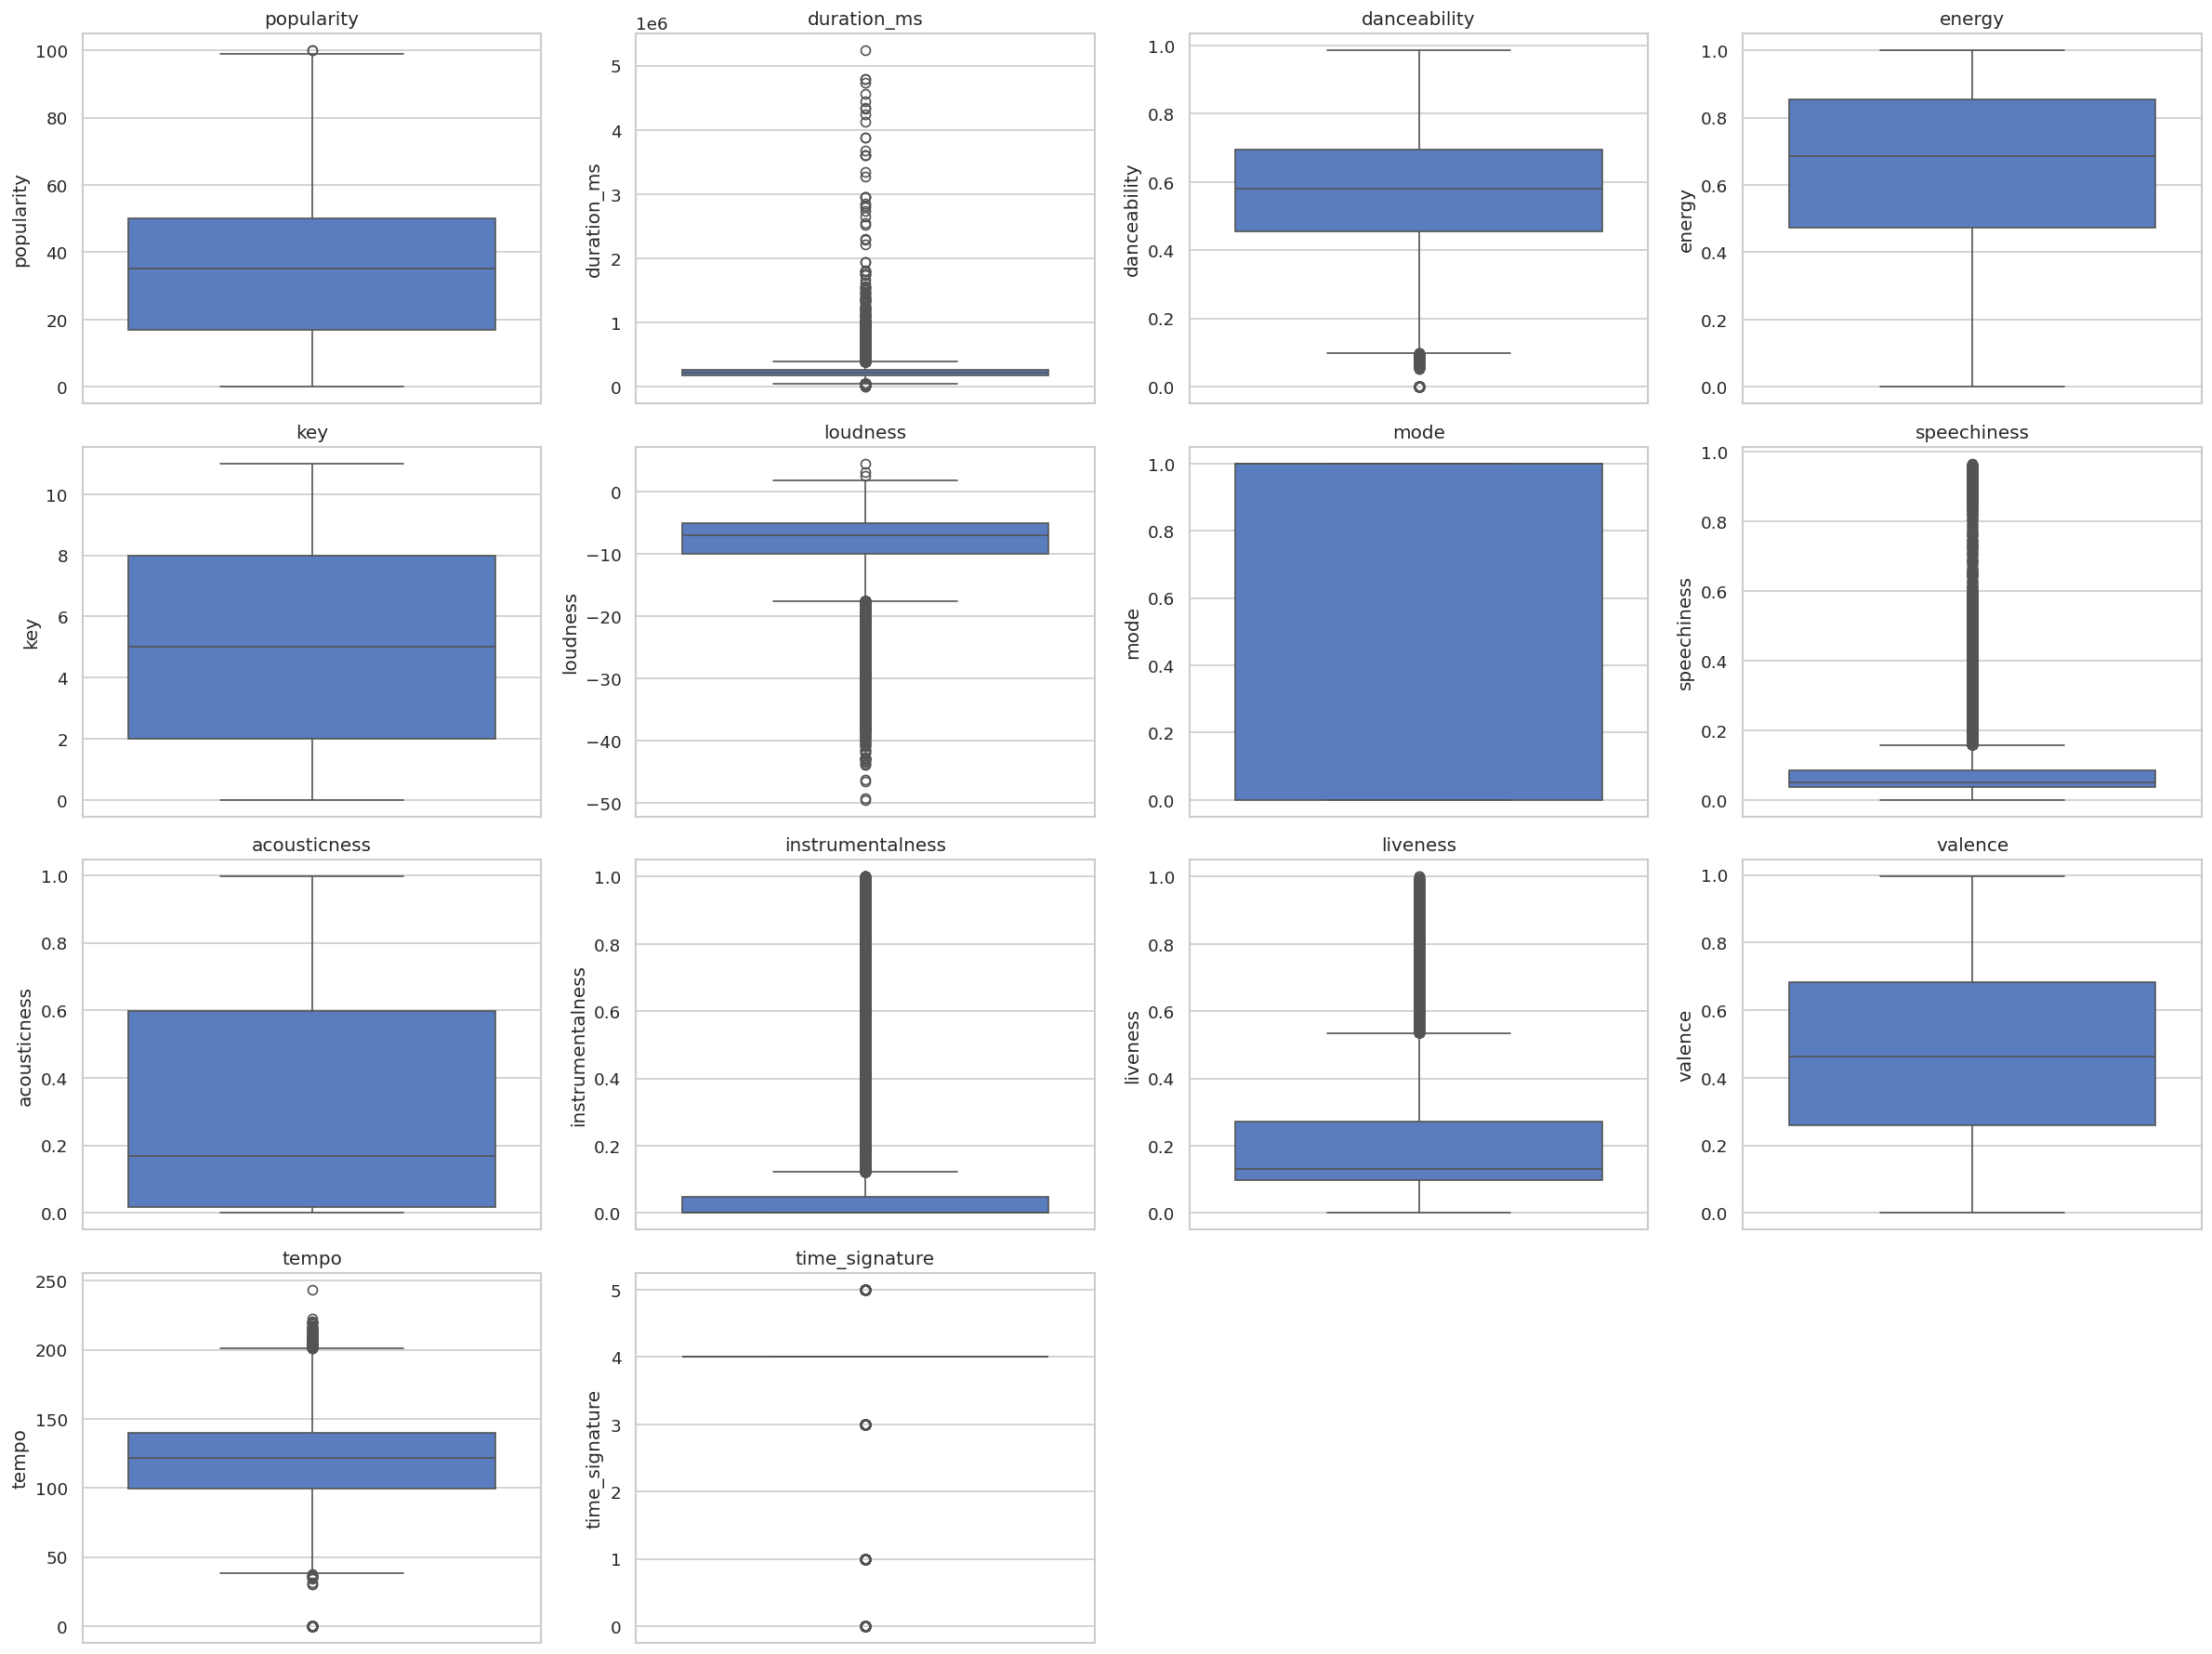

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memilih kolom numerik
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Membuat boxplot
plt.figure(figsize=(20, 15))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()



> Boxplot di atas menampilkan distribusi setiap fitur numerik beserta potensi outlier. Fitur seperti popularity, duration_ms, dan loudness umumnya menunjukkan sebaran yang lebar dengan beberapa titik ekstrem.



**12. Cek duplikat — menghitung jumlah baris yang merupakan duplikat persis dari baris lain dalam dataset.**

In [ ]:
df.duplicated().sum()

np.int64(450)

# DATA CLEANING

**1. Heatmap missing values sebelum cleaning** — visualisasi berikut menampilkan pola sebaran nilai kosong di seluruh dataset. Setiap baris yang memiliki missing value akan terlihat sebagai garis terang pada heatmap.

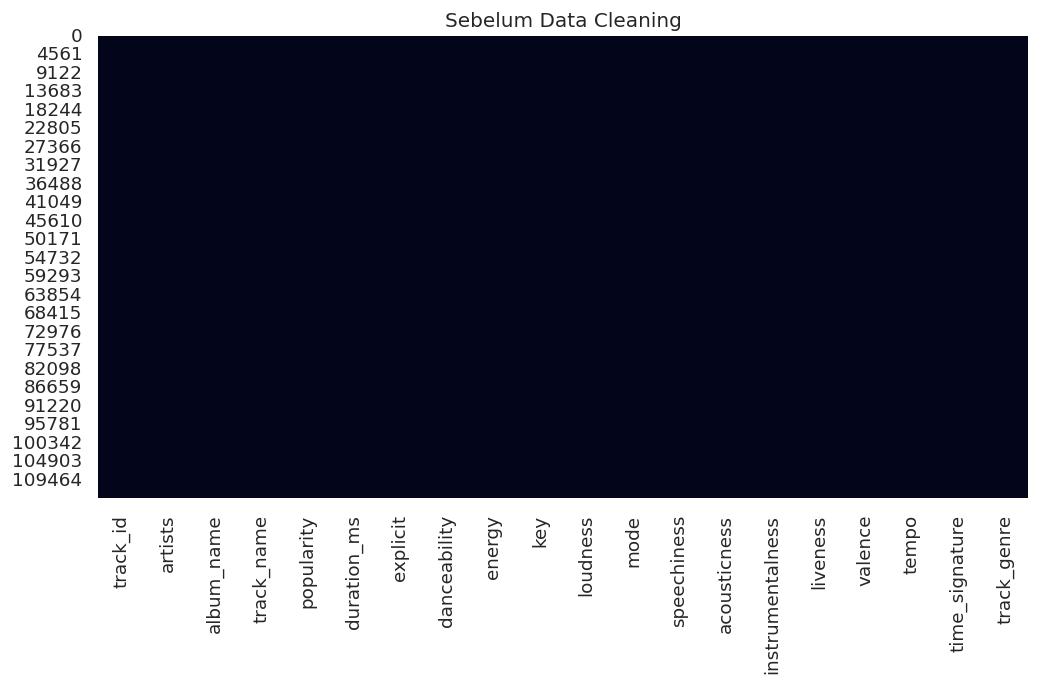

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Sebelum Data Cleaning")
plt.show()

> Heatmap di atas menunjukkan distribusi missing values pada dataset sebelum dilakukan pembersihan. Kolom yang memiliki banyak nilai kosong tampak sebagai area terang yang menonjol. Pola ini memberikan gambaran kolom mana yang memerlukan penanganan prioritas, apakah melalui penghapusan baris atau imputasi nilai.



**2. Hapus missing values**

In [ ]:
df.dropna(inplace=True)

**3. Verifikasi setelah hapus missing values** — memastikan tidak ada lagi nilai null yang tersisa.

In [ ]:
df.isnull().sum()

,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


**4. Hitung jumlah outlier sebelum handling (ringkasan)**

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers

print("Jumlah outlier per kolom (sebelum handling):")
for col, count in outlier_summary.items():
    print(f"  {col}: {count}")

Jumlah outlier per kolom (sebelum handling):
  popularity: 2
  duration_ms: 5616
  danceability: 620
  energy: 0
  key: 0
  loudness: 6173
  mode: 0
  speechiness: 13211
  acousticness: 0
  instrumentalness: 25246
  liveness: 8642
  valence: 0
  tempo: 617
  time_signature: 12157


**5. IQR Capping (Winsorization)**

In [ ]:
cols_to_cap = ['popularity', 'duration_ms', 'danceability', 'energy',
               'loudness', 'speechiness', 'acousticness',
               'instrumentalness', 'liveness', 'valence', 'tempo']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outlier handling selesai. Shape dataset:", df.shape)

Outlier handling selesai. Shape dataset: (113999, 20)


**6. Verifikasi dengan boxplot sesudah handling**

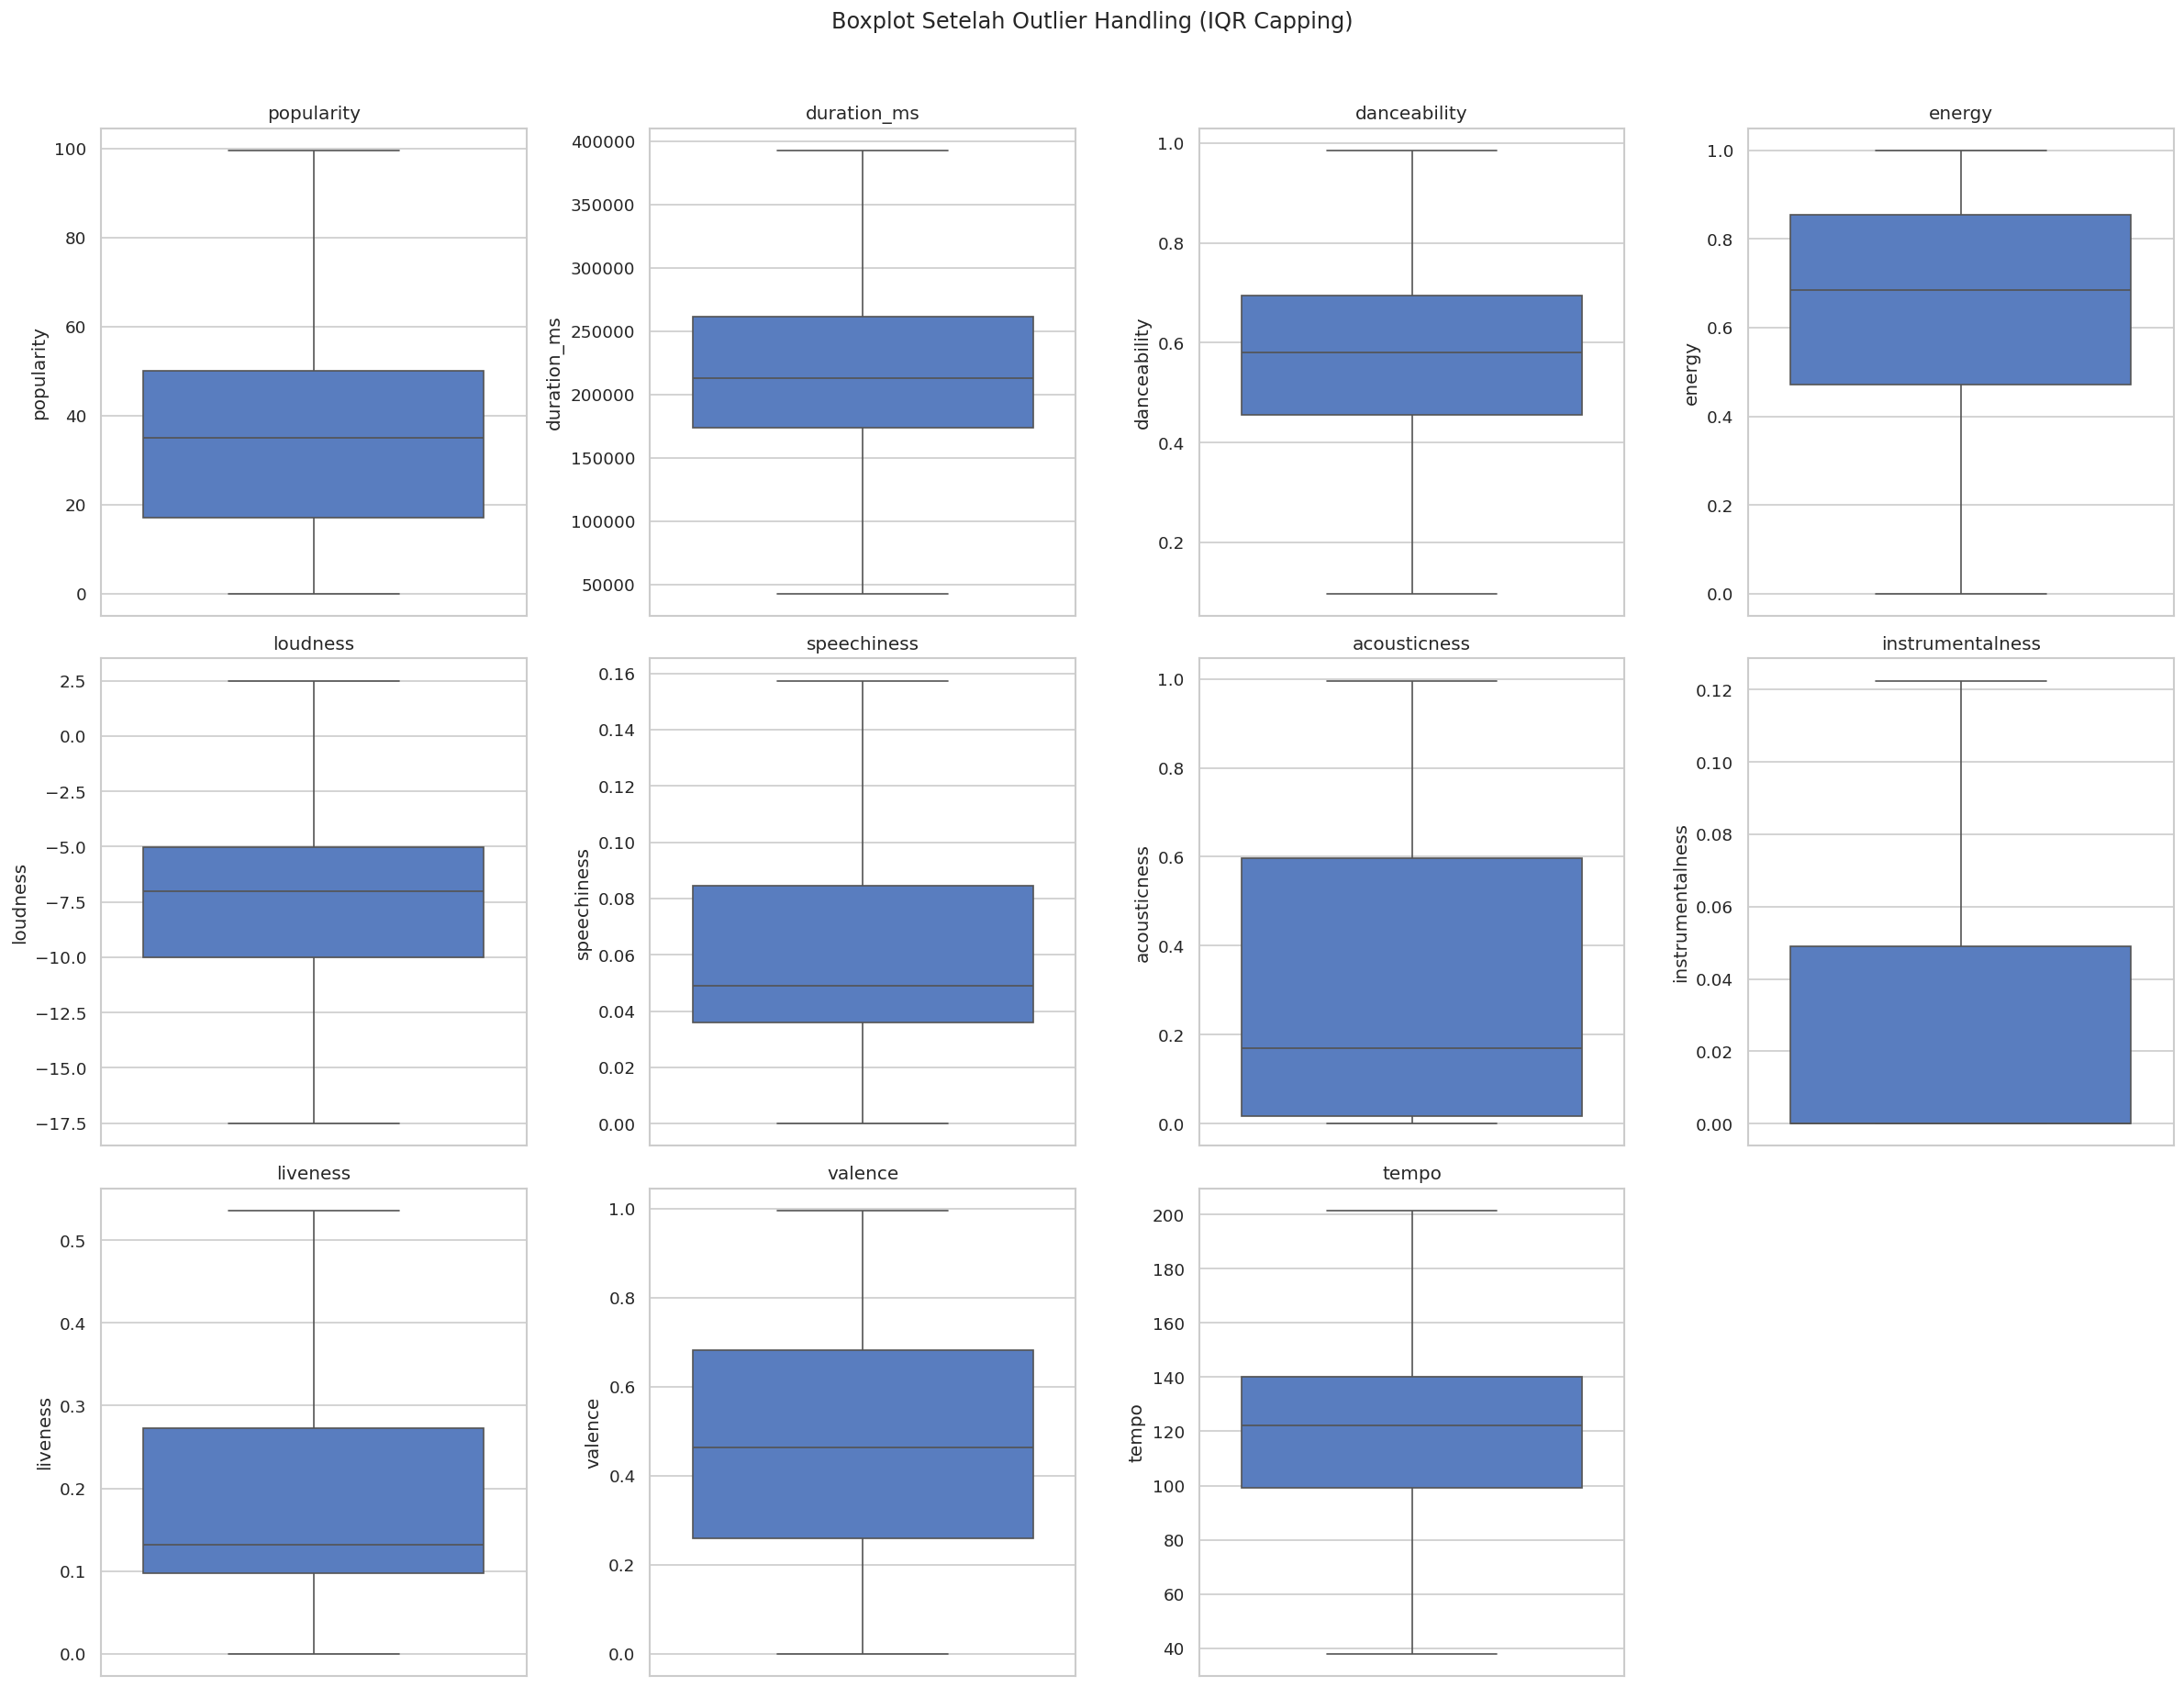

In [ ]:
# Boxplot sesudah outlier handling — verifikasi visual
plt.figure(figsize=(20, 15))

for i, col in enumerate(cols_to_cap, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.suptitle('Boxplot Setelah Outlier Handling (IQR Capping)', y=1.02)
plt.tight_layout()
plt.show()



> Penanganan outlier dilakukan menggunakan metode IQR Capping (Winsorization), yaitu dengan menetapkan batas bawah sebesar Q1 − 1,5×IQR dan batas atas sebesar Q3 + 1,5×IQR pada setiap fitur numerik yang relevan. Nilai yang melampaui batas tersebut tidak dihapus, melainkan di-clip ke nilai batasnya. Pendekatan ini dipilih karena dataset Spotify mencakup berbagai jenis konten audio — termasuk podcast, live performance, dan spoken word — yang secara alami menghasilkan variasi tinggi pada fitur seperti duration_ms, speechiness, dan instrumentalness. Menghapus baris outlier berisiko membuang data yang sesungguhnya valid dan representatif. Kolom bertipe biner seperti mode dan explicit tidak ikut di-cap karena hanya memiliki nilai 0 dan 1 secara by design.



**7. Hapus baris duplikat**

In [ ]:
df.drop_duplicates(inplace=True)

**8. Verifikasi setelah hapus duplikat** — memastikan nilai duplikat sudah 0.

In [ ]:
df.duplicated().sum()

np.int64(0)

**9. Normalisasi teks kolom kategorikal**

In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

> semua nilai teks diubah menjadi huruf kecil (lowercase) dan spasi berlebih dihilangkan menggunakan .str.strip().str.lower(). Langkah ini mencegah duplikat tersembunyi akibat perbedaan kapitalisasi, misalnya 'Pop' vs 'pop'.

**10. Cek tipe data setelah cleaning** — memastikan tidak ada perubahan tipe data yang tidak diinginkan.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113549 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113549 non-null  object 
 1   artists           113549 non-null  object 
 2   album_name        113549 non-null  object 
 3   track_name        113549 non-null  object 
 4   popularity        113549 non-null  float64
 5   duration_ms       113549 non-null  int64  
 6   explicit          113549 non-null  bool   
 7   danceability      113549 non-null  float64
 8   energy            113549 non-null  float64
 9   key               113549 non-null  int64  
 10  loudness          113549 non-null  float64
 11  mode              113549 non-null  int64  
 12  speechiness       113549 non-null  float64
 13  acousticness      113549 non-null  float64
 14  instrumentalness  113549 non-null  float64
 15  liveness          113549 non-null  float64
 16  valence           113549 

**11. Heatmap missing values sesudah cleaning**

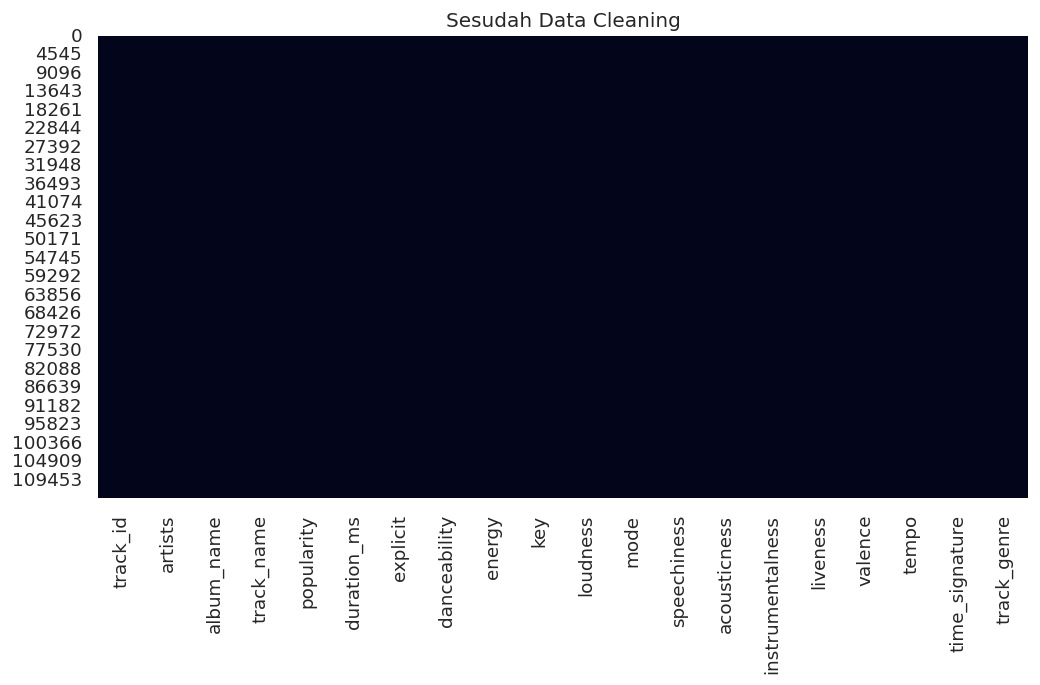

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Sesudah Data Cleaning")
plt.show()

# FEATURE ENGINEERING

Feature engineering adalah proses menciptakan atau mentransformasi variabel baru dari data yang sudah ada guna meningkatkan kualitas dan keterbacaan analisis. Pada tahap ini dilakukan empat transformasi utama untuk memperkaya dataset sebelum eksplorasi dilakukan.

**1. Konversi durasi dari milidetik ke menit**

In [ ]:
df['duration_min'] = round(df['duration_ms'] / 60000, 2)

> Note: Mengubah durasi lagu dari milidetik menjadi menit agar lebih mudah dipahami.



**2. Kategori popularitas (Low / Medium / High)**

In [ ]:
df['popularity_category'] = pd.qcut(
    df['popularity'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

> Note: Mengelompokkan popularitas lagu menjadi Low, Medium, dan High menggunakan metode quantile (qcut) berdasarkan distribusi data.



**3. Kategori tempo (Slow / Medium / Fast)**

In [ ]:
df['tempo_category'] = pd.qcut(
    df['tempo'],
    q=3,
    labels=['Slow', 'Medium', 'Fast'],
    duplicates='drop'
)

> Note: Mengelompokkan tempo lagu menjadi Slow, Medium, dan Fast menggunakan metode quantile (qcut) berdasarkan distribusi data.



4. Encoding variabel explicit

In [ ]:
df['explicit_encoded'] = df['explicit'].astype(int)

> Note: Mengubah nilai boolean (True/False) menjadi numerik (1/0) agar dapat digunakan dalam analisis statistik atau machine learning.



**5. Tampilkan hasil feature engineering**

In [ ]:
print(df[['duration_min',
          'popularity_category',
          'tempo_category',
          'explicit_encoded']].head())

   duration_min popularity_category tempo_category  explicit_encoded
0          3.84                High           Slow                 0
1          2.49                High           Slow                 0
2          3.51                High           Slow                 0
3          3.37                High           Fast                 0
4          3.31                High         Medium                 0


**6. Distribusi kategori** — menampilkan jumlah data pada setiap kategori popularitas dan tempo untuk memastikan distribusi seimbang.

In [ ]:
# Informasi jumlah data tiap kategori
print("\nDistribusi Popularity Category:")
print(df['popularity_category'].value_counts())

print("\nDistribusi Tempo Category:")
print(df['tempo_category'].value_counts())


Distribusi Popularity Category:
popularity_category
Medium    38628
Low       38507
High      36414
Name: count, dtype: int64

Distribusi Tempo Category:
tempo_category
Slow      37850
Fast      37850
Medium    37849
Name: count, dtype: int64


# EXPORT DATASET CLEAN

In [ ]:
df.to_csv("dataset_clean.csv", index=False)

# EXPLORATORY DATA ANALYSIS (EDA)

Menampilkan jumlah lagu per genre untuk seluruh genre dalam dataset.

In [ ]:
genre_count = df['track_genre'].value_counts()

print(genre_count.head)

<bound method NDFrame.head of track_genre
acoustic      1000
british       1000
electronic    1000
emo           1000
funk          1000
              ... 
honky-tonk     981
dance          965
german         963
classical      933
romance        904
Name: count, Length: 114, dtype: int64>


Univariate

**1. Bar Chart — Top 10 Genre Musik Terbanyak**

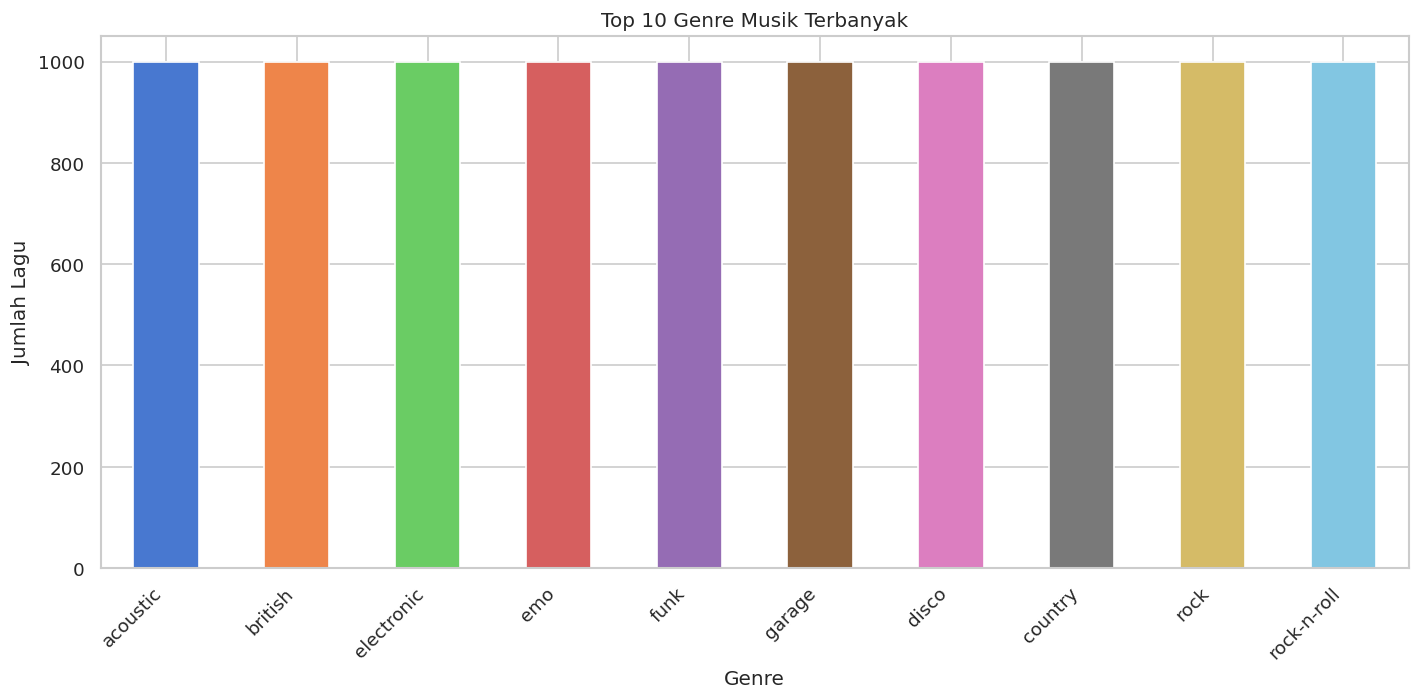

In [ ]:
top_genre = df['track_genre'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_genre.plot(kind='bar', color=sns.color_palette("muted", 10))
plt.title('Top 10 Genre Musik Terbanyak')
plt.xlabel('Genre')
plt.ylabel('Jumlah Lagu')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> 📊 Insight: Grafik batang ini menampilkan 10 genre dengan jumlah lagu terbanyak dalam dataset. Distribusi yang relatif merata antar genre teratas mengindikasikan bahwa dataset dirancang untuk merepresentasikan berbagai genre secara proporsional, sehingga analisis lintas genre dapat dilakukan tanpa risiko bias yang signifikan terhadap genre tertentu.



**2. Bar Chart — Top 10 Genre Berdasarkan Rata-rata Popularitas**

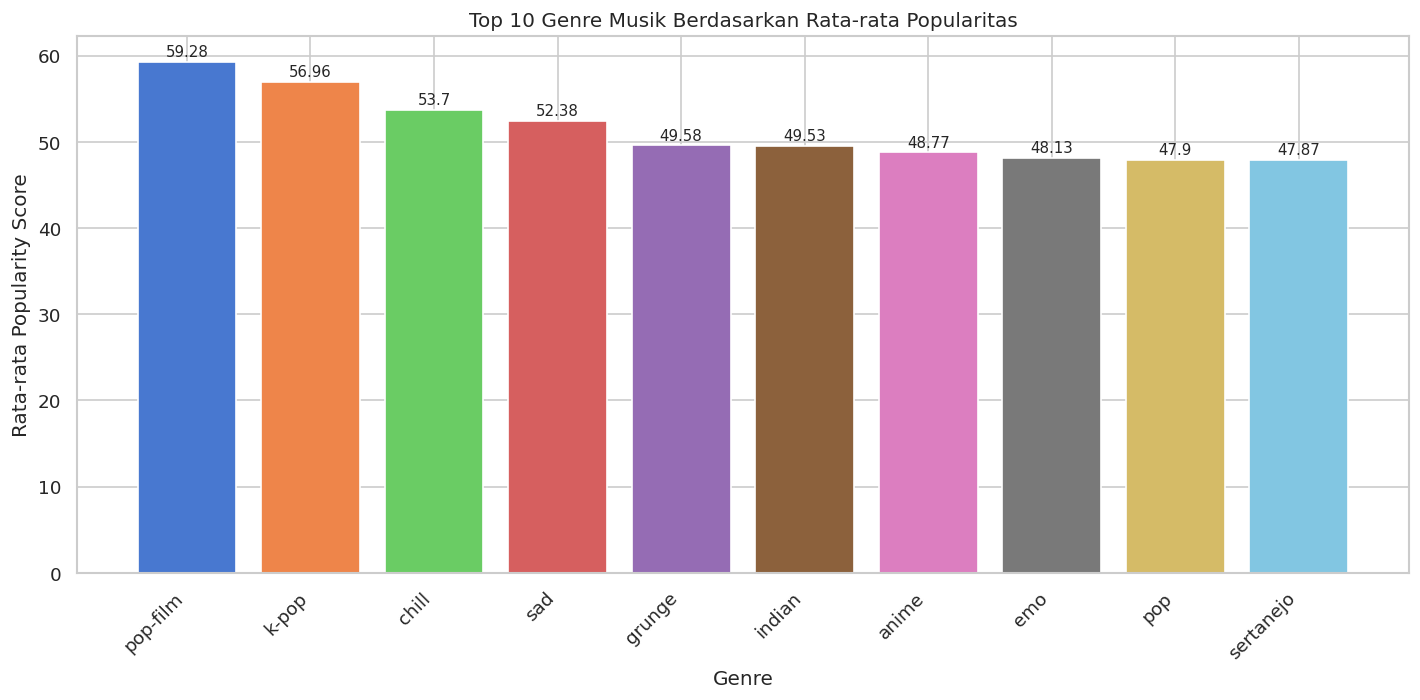

In [ ]:
genre_popularity = (
    df.groupby('track_genre')['popularity']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .round(2)
)

plt.figure(figsize=(12, 6))
bars = plt.bar(genre_popularity.index, genre_popularity.values,
               color=sns.color_palette("muted", 10))
plt.title('Top 10 Genre Musik Berdasarkan Rata-rata Popularitas')
plt.xlabel('Genre')
plt.ylabel('Rata-rata Popularity Score')
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, genre_popularity.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()



> 📊 Insight: Berbeda dari grafik jumlah lagu sebelumnya, visualisasi ini menunjukkan genre mana yang paling diapresiasi pendengar Spotify secara rata-rata. Genre dengan skor popularitas rata-rata tertinggi menjadi kandidat utama dalam strategi promosi konten dan pengembangan playlist yang dipersonalisasi, karena mencerminkan preferensi nyata pendengar di platform.



**3. Histogram — Distribusi Popularity**

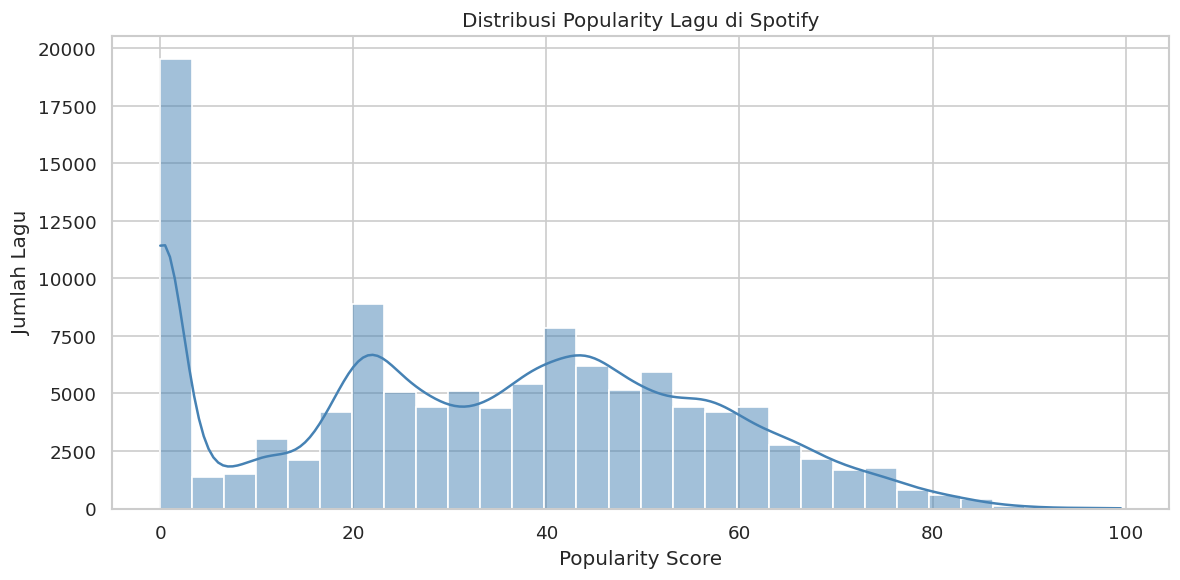

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], bins=30, kde=True, color='steelblue')
plt.title('Distribusi Popularity Lagu di Spotify')
plt.xlabel('Popularity Score')
plt.ylabel('Jumlah Lagu')
plt.tight_layout()
plt.show()



> 📊 Insight: Histogram ini menampilkan sebaran skor popularitas seluruh lagu dalam dataset. Distribusi yang cenderung tidak merata dengan konsentrasi di rentang popularitas rendah hingga menengah mencerminkan fenomena umum industri musik digital, di mana hanya sebagian kecil lagu berhasil meraih popularitas tinggi sementara mayoritas lagu bersaing di tingkat yang lebih rendah. Kondisi ini menegaskan pentingnya memahami karakteristik lagu populer sebagai acuan strategi produksi dan promosi.



Bivariate

**1. Hitung jumlah lagu explicit vs non-explicit**

In [ ]:
explicit_count = df['explicit'].value_counts()

print(explicit_count)

explicit
False    103831
True       9718
Name: count, dtype: int64


**2. Boxplot — Popularitas Berdasarkan Explicit Content**

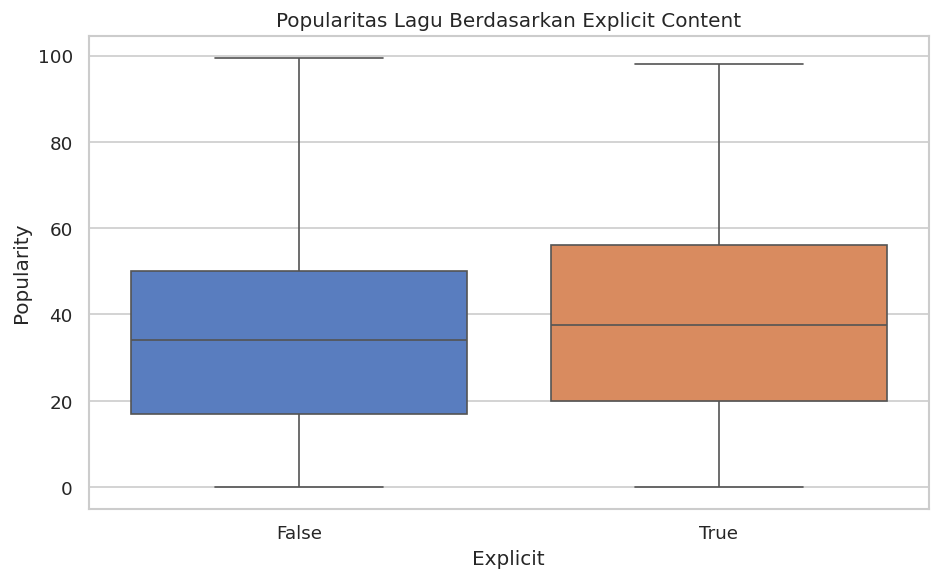

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='explicit', y='popularity', data=df, palette='muted')
plt.title('Popularitas Lagu Berdasarkan Explicit Content')
plt.xlabel('Explicit')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

> 📊Insight: Boxplot ini membandingkan distribusi nilai popularity antara lagu explicit dan non-explicit. Jika median popularitas lagu explicit lebih tinggi, hal ini mengindikasikan adanya preferensi pendengar terhadap konten eksplisit yang umumnya mendominasi genre hip-hop dan rap. Namun perbedaan ini tidak serta-merta bersifat kausal karena genre yang secara alami lebih populer juga cenderung lebih banyak mengandung konten eksplisit, sehingga genre menjadi variabel pengganggu yang perlu dipertimbangkan dalam interpretasi.



**3. Boxplot — Danceability Berdasarkan Explicit Content**

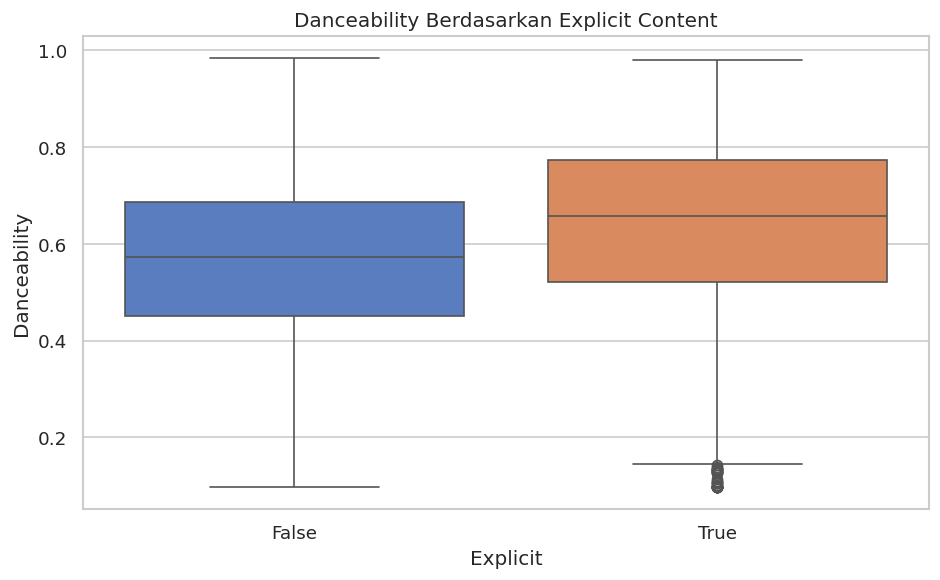

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='explicit', y='danceability', data=df, palette='muted')
plt.title('Danceability Berdasarkan Explicit Content')
plt.xlabel('Explicit')
plt.ylabel('Danceability')
plt.tight_layout()
plt.show()



> 📊 Insight: Boxplot ini membandingkan nilai danceability antara lagu explicit dan non-explicit. Lagu explicit cenderung memiliki nilai danceability lebih tinggi, yang berkorelasi dengan dominasi genre hip-hop, R&B, dan rap dalam kategori explicit. Genre-genre tersebut dirancang dengan ritme kuat dan beat teratur sehingga secara inheren menghasilkan skor danceability tinggi, mempertegas keterkaitan antara konten eksplisit dengan karakteristik ritme lagu.



**4. Bar Chart — Profil Rata-rata Fitur Audio per Kategori Popularitas**

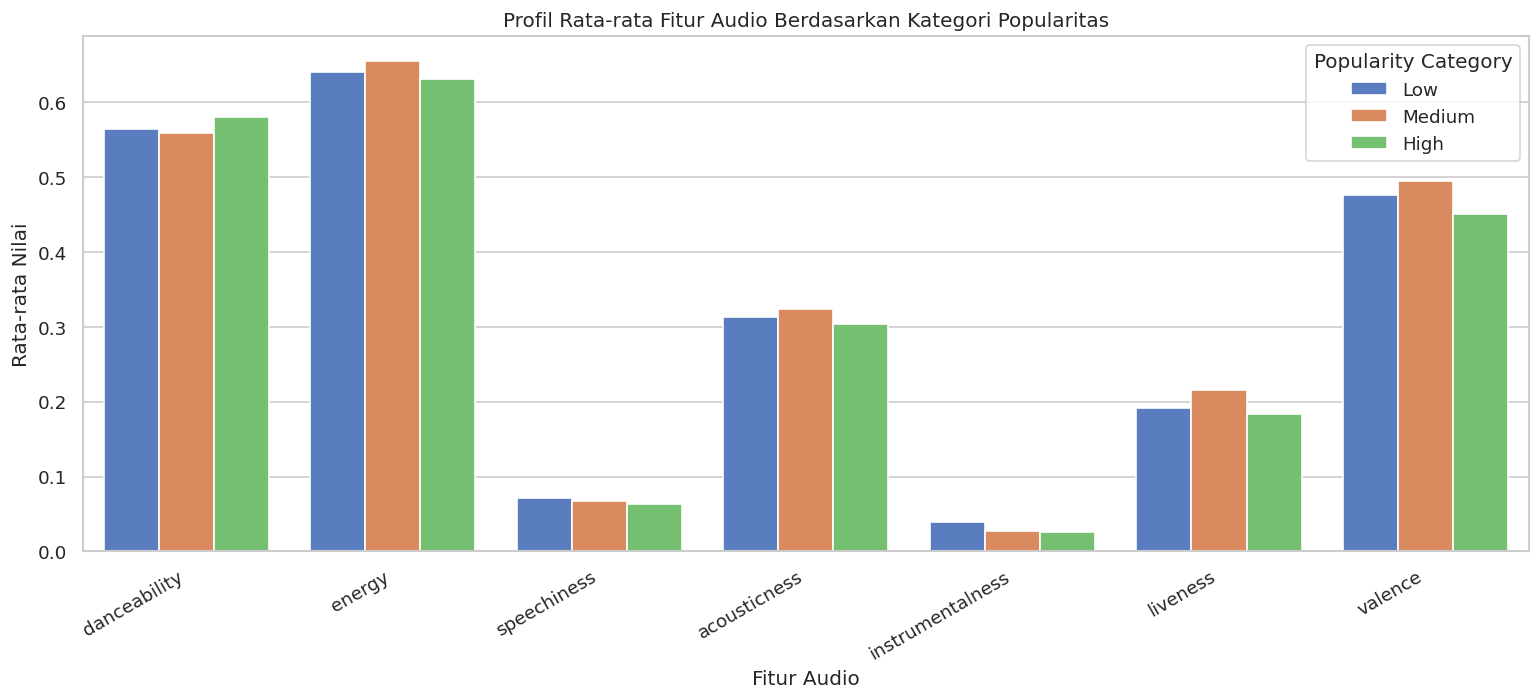

In [ ]:
audio_features = ['danceability', 'energy', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence']

profile = df.groupby('popularity_category')[audio_features].mean().round(3)
profile_melted = profile.reset_index().melt(
    id_vars='popularity_category',
    var_name='Feature',
    value_name='Mean Value'
)

plt.figure(figsize=(13, 6))
sns.barplot(
    data=profile_melted,
    x='Feature',
    y='Mean Value',
    hue='popularity_category',
    hue_order=['Low', 'Medium', 'High'],
    palette='muted'
)
plt.title('Profil Rata-rata Fitur Audio Berdasarkan Kategori Popularitas')
plt.xlabel('Fitur Audio')
plt.ylabel('Rata-rata Nilai')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Popularity Category')
plt.tight_layout()
plt.show()



> 📊 Insight: Grafik ini membandingkan profil rata-rata fitur audio antara lagu berkategori Low, Medium, dan High popularity. Lagu dengan popularitas tinggi cenderung memiliki nilai danceability dan valence lebih tinggi, mengindikasikan bahwa lagu yang ceria dan mudah untuk berdansa memiliki daya tarik lebih luas di kalangan pendengar. Sebaliknya, instrumentalness dan acousticness cenderung lebih tinggi pada lagu popularitas rendah, mencerminkan bahwa konten instrumental atau akustik memiliki segmen pendengar yang lebih niche dan spesifik.



Multivariate

**1. Scatter Plot — Energy vs Danceability berdasarkan Popularity**

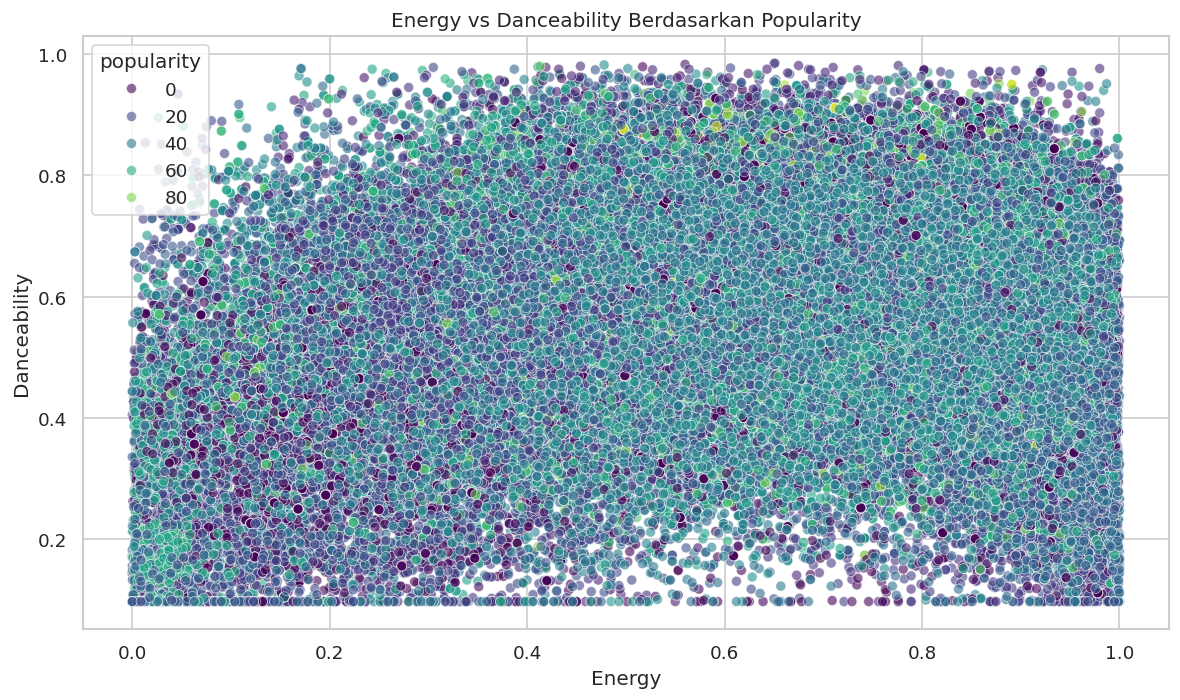

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='energy',
    y='danceability',
    hue='popularity',
    data=df,
    palette='viridis',
    alpha=0.6
)
plt.title('Energy vs Danceability Berdasarkan Popularity')
plt.xlabel('Energy')
plt.ylabel('Danceability')
plt.tight_layout()
plt.show()



> 📊 Insight: Scatter plot ini menggabungkan tiga dimensi sekaligus: energy, danceability, dan popularity yang direpresentasikan melalui gradasi warna. Lagu-lagu populer tampak tersebar di berbagai kombinasi energy dan danceability, namun konsentrasi titik dengan popularitas tinggi sedikit lebih padat pada area danceability menengah hingga tinggi. Temuan ini mengonfirmasi bahwa danceability memiliki kontribusi moderat terhadap popularitas meskipun bukan satu-satunya penentu.



**2. Scatter Plot — Energy vs Valence berdasarkan Explicit dan Popularity**

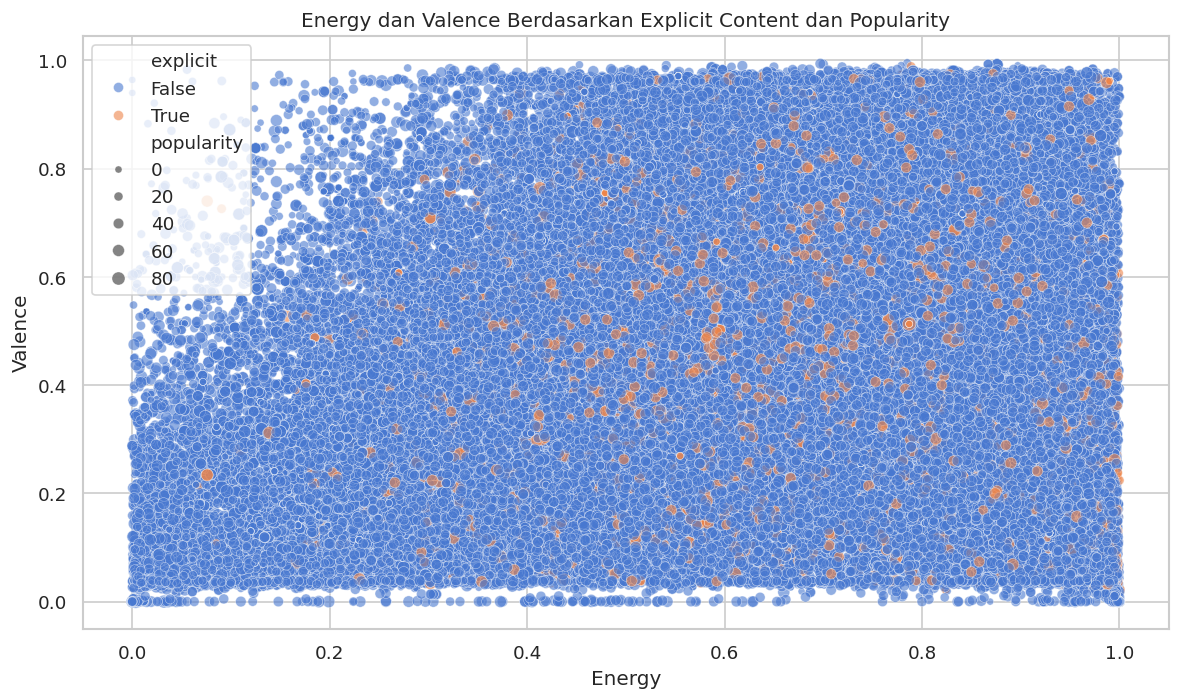

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='energy',
    y='valence',
    hue='explicit',
    size='popularity',
    data=df,
    alpha=0.6,
    palette='muted'
)
plt.title('Energy dan Valence Berdasarkan Explicit Content dan Popularity')
plt.xlabel('Energy')
plt.ylabel('Valence')
plt.tight_layout()
plt.show()

📊 Insight: Visualisasi ini menggabungkan empat dimensi sekaligus yaitu energy, valence, explicit, dan popularity dalam satu tampilan. Lagu explicit cenderung tersebar di area valence moderat hingga rendah, mengindikasikan bahwa konten eksplisit tidak selalu berkorelasi dengan lagu yang bernuansa ceria. Titik-titik berukuran besar yang merepresentasikan popularitas tinggi tersebar merata di berbagai kombinasi energy dan valence, mempertegas bahwa tidak ada satu pun kombinasi fitur audio yang secara konsisten menjamin popularitas tinggi di platform streaming.

**3. Heatmap Korelasi Fitur Audio Spotify**

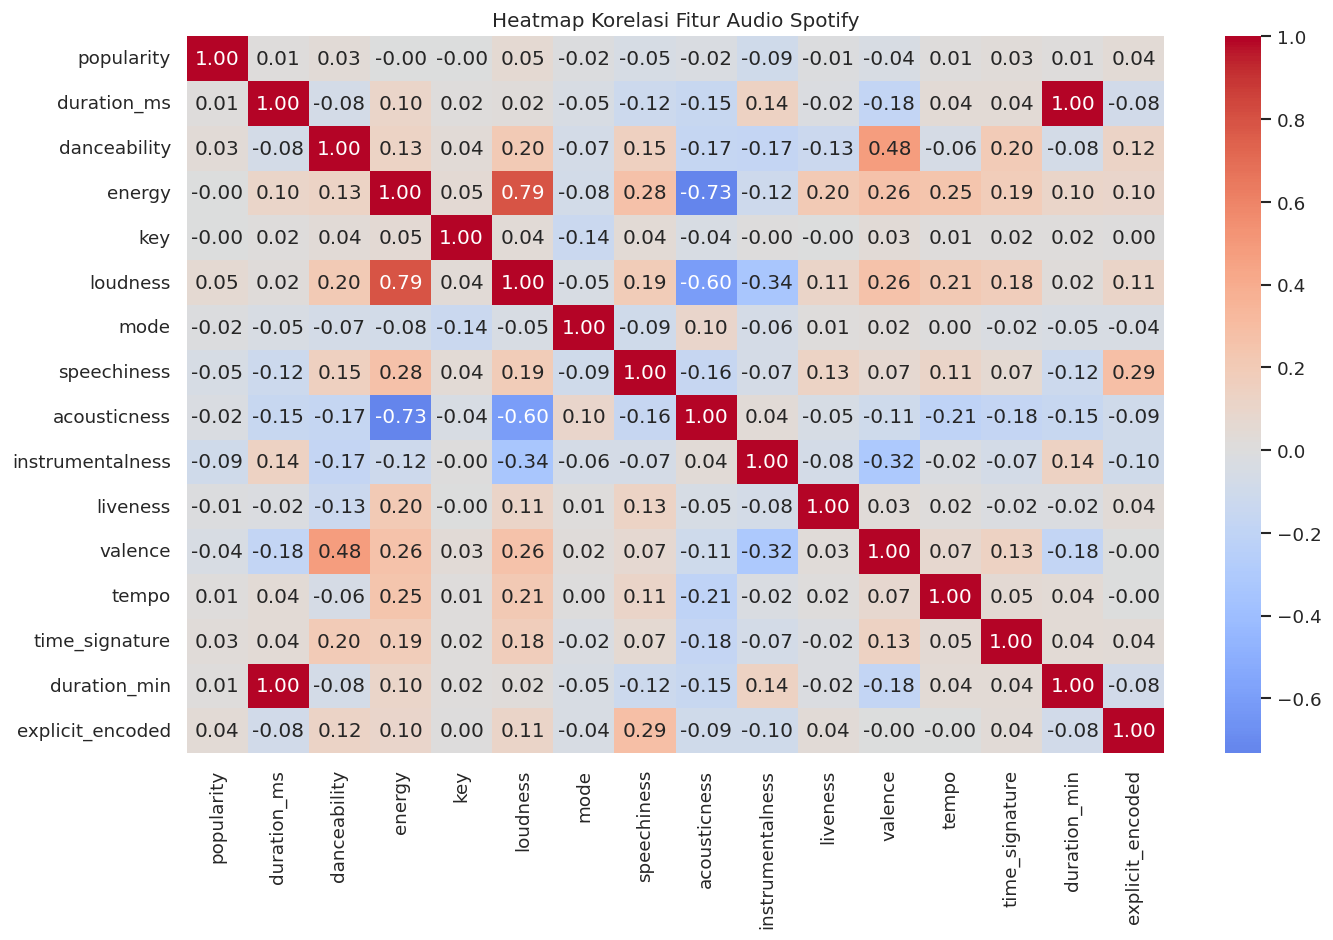

In [ ]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    center=0
)
plt.title('Heatmap Korelasi Fitur Audio Spotify')
plt.tight_layout()
plt.show()



> 📊 Insight: Heatmap korelasi ini merangkum seluruh hubungan linear antar fitur audio numerik dalam satu tampilan. Pasangan fitur dengan korelasi positif kuat adalah energy–loudness (r ≈ 0.76), menunjukkan bahwa lagu berenergi tinggi hampir selalu diproduksi dengan volume keras. energy–acousticness memiliki korelasi negatif kuat (r ≈ -0.73), mengonfirmasi bahwa instrumen akustik menghasilkan karakteristik energi yang berbeda dari instrumen elektronik. valence–danceability berkorelasi positif moderat, mencerminkan bahwa lagu yang terdengar ceria dan positif cenderung memiliki ritme yang lebih mengundang untuk berdansa. Sementara itu, popularity tidak berkorelasi signifikan dengan fitur audio manapun, mengindikasikan bahwa aspek non-teknis seperti promosi, artis, dan waktu rilis memainkan peran yang lebih besar dalam menentukan popularitas sebuah lagu.



**4. Korelasi Variabel Numerik**

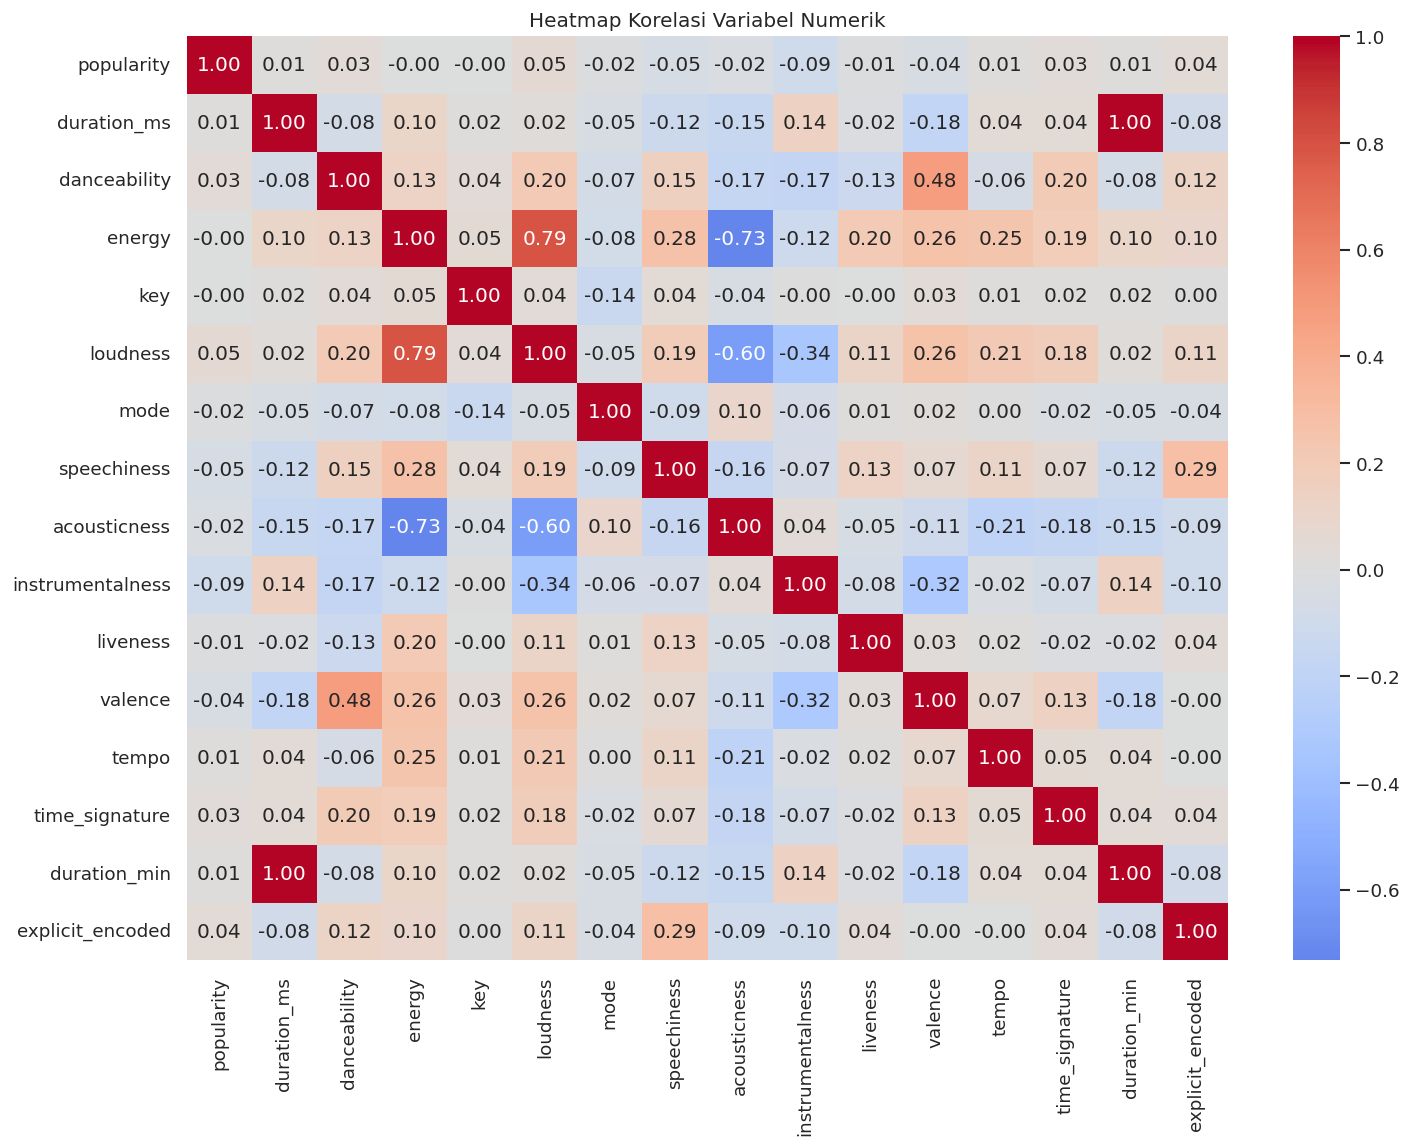

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))
corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0
)

plt.title('Heatmap Korelasi Variabel Numerik')
plt.show()

> 📊 Insight: Heatmap korelasi menunjukkan beberapa hubungan yang cukup kuat antar fitur audio. energy dan loudness memiliki korelasi positif yang tinggi, mengindikasikan bahwa lagu yang berenergi tinggi cenderung lebih keras. Sebaliknya, energy dan acousticness berkorelasi negatif kuat, yang berarti lagu akustik umumnya memiliki energi rendah. valence dan danceability juga menunjukkan korelasi positif moderat, mencerminkan bahwa lagu yang ceria cenderung lebih mudah untuk digunakan berdansa. Fitur popularity tidak menunjukkan korelasi tinggi terhadap fitur audio manapun, mengindikasikan bahwa popularitas lagu dipengaruhi oleh faktor yang lebih kompleks di luar karakteristik audio semata.